In [1]:
#%pip install --upgrade numpy scipy matplotlib seaborn yt

import numpy as np
from scipy.stats import binned_statistic
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib as mpl
from matplotlib.colors import LogNorm
import matplotlib.image as image
import seaborn as sb #for different color palette
import yt
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
plt.style.use('classic')

def figsize(scale):
     fig_width_pt = 1000 #510.0 #from /the/textwidth for paper!!!                       # Get this from LaTeX using \the\textwidth -> 415.41025, for multiplot side by side: 450.41025
     inches_per_pt = 1.0/72.27                       # Convert pt to inch
     golden_mean = (np.sqrt(5.0)-0.4)/2.0            # Aesthetic ratio (changed from -1.0 to -0.9)
     fig_width = fig_width_pt*inches_per_pt*scale    # width in inches, for dedicated and all emissions: 0.5*...
     fig_height = fig_width*0.6   #0.6       # height in inches, for dedicated and all emissions: 2*..., for rew012: 0.4*...
     fig_size = [fig_width,fig_height]
     return fig_size


font = {
    'font.family':'serif',
    'font.style': 'normal',
    'axes.labelsize': 22, #10
    'legend.fontsize': 20, #8
    'xtick.labelsize': 20, #8
    'ytick.labelsize': 20, #8
    'figure.figsize': figsize(1.0),
}
mpl.rcParams.update(font)
#mpl.rcParams['axes.linewidth'] = 1.5 #set the value globally
    

#mpl.rcParams['axes.linewidth'] = 1.25 #set the value globally 
mpl.rcParams['figure.facecolor'] = 'w'

cp = [(0.14573579, 0.29354139, 0.49847009), (0.9333333333333333, 0.5215686274509804, 0.2901960784313726),(0.48942421, 0.72854938, 0.56751036)]


# KG run

### Model Parameters (see also inputs file)

In [3]:
alpha = 0.5
beta = 20

m = 1.4002212706340354e-05 # inflaton mass in Planck mass
phi0 = 0.15038139982855017 # initial field value in Planck mass

M = 0.009973557010035817 # computed from M_pl/beta where M_pl is the reduced Planck mass, 
                         # i.e. M = 1/sqrt(8*pi)/beta in Planck mass

res_param = 0.5*(1-alpha-0.1*(1-alpha)**2)*beta #quantifies strength of resonance, see Richard's resonance papers
print('resonance param: ',res_param)

A = 1/phi0 
B = m*M**(1-alpha)*phi0**(-1+alpha)
r = 6/(2+2*alpha)
s = 3*(2-2*alpha)/(2+2*alpha)

L = 10 # box size in program units (l_pr)
N = 64
# N = 128 
#N = 256 # grid size -> N^3
dx = L/N # cell width

resonance param:  4.75


### read in KG final snapshot

In [68]:
# read in snapshot with yt
# path_kg = '/home/uni09/cosmo/beggeme/early_universe/post_resonance/KG/'
path_kg = '/user/niki.suckau/u10965/.project/dir.scratch-scc/scalarverse/Exec/Inflation/ComovSingleField/Output_64/'

#ds = yt.load(path_kg+'plt86000',hint='NyxDataset')
#ds = yt.load(path_kg+'plt86000',hint='AMReXDataset')
ds = AMReXDataset(path_kg+'plt10000', units_override = {"length_unit" : (100. , "l_pl")})

yt : [WARNING  ] 2025-01-03 13:22:57,501 Overriding code units: Use this option only if you know that the dataset doesn't define the units correctly or at all.
yt : [INFO     ] 2025-01-03 13:22:57,501 Overriding length_unit: 100.0 l_pl.
yt : [INFO     ] 2025-01-03 13:22:57,533 Parameters: current_time              = 500.000000000079
yt : [INFO     ] 2025-01-03 13:22:57,534 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-01-03 13:22:57,534 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-01-03 13:22:57,535 Parameters: domain_right_edge         = [10. 10. 10.]


 ds.field_list outputs fields stored in snapshot: 
 - 'Edens' is the total energy density $\rho = \frac{1}{2}\dot\varphi^2+\frac{1}{2a^2}|\nabla\varphi|^2 + V(\varphi)$ consisting of a kinetic term, gradient term and the field potential. Output is in natural units, i.e. (Planck mass)$^4$.
 - 'KGf' is the KG field in Planck units
 - 'KGfpr' is the KG field in code units
 - 'KGfdens'is KG field density in Planck units
 - 'KGfv' is $\dot\varphi$ is Planck units
 - 'KGfVpr' is $\dot\varphi$ in code units

In [69]:
ds.field_list

[('boxlib', 'Edens'),
 ('boxlib', 'KGf'),
 ('boxlib', 'KGfVpr'),
 ('boxlib', 'KGfdens'),
 ('boxlib', 'KGfpr'),
 ('boxlib', 'KGfv')]

### Plot KG field 
(units in Plot are physical code units, i.e. scale factor evolution is taken into account)

yt : [INFO     ] 2025-01-03 13:23:00,427 xlim = 0.000000 10.000000
yt : [INFO     ] 2025-01-03 13:23:00,428 ylim = 0.000000 10.000000
yt : [INFO     ] 2025-01-03 13:23:00,430 xlim = 0.000000 10.000000
yt : [INFO     ] 2025-01-03 13:23:00,431 ylim = 0.000000 10.000000
yt : [INFO     ] 2025-01-03 13:23:00,433 Making a fixed resolution buffer of (('boxlib', 'KGf')) 800 by 800



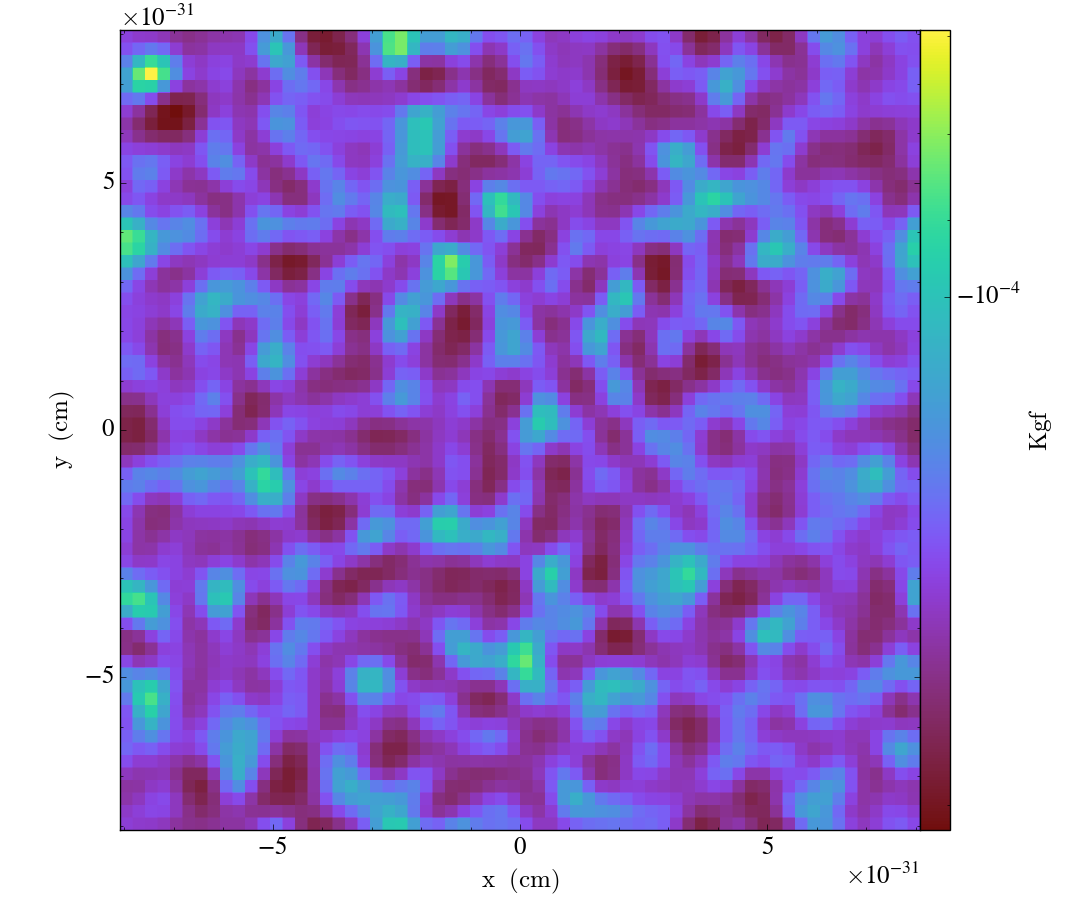

In [70]:
slc = yt.SlicePlot(ds,'z','KGf')
slc.show()


### Compute and plot density power spectrum

In [ ]:
max_level = ds.index.max_level
ref = int(np.product(ds.ref_factors[0:max_level]))
low = ds.domain_left_edge
dims = ds.domain_dimensions*ref
# covering_grid guarantess that all grids are read in properly [density field is not mixed up]
cube = ds.covering_grid(level=max_level, left_edge=low,dims=dims,fields=['Edens']) 
dens = cube['Edens'].value # in code units
overdens = dens/np.mean(dens) - 1

# Fourier transform to compute power spectrum

kxList = np.fft.fftfreq(N,dx)*2.0*np.pi
kx3d, ky3d, kz3d = np.meshgrid(kxList, kxList, kxList, indexing="ij")
kk = np.sqrt(kx3d**2 + ky3d**2 + kz3d**2)
spectrum_3D = np.abs(np.fft.fftn(overdens)*(dx**3))**2/L**3 

# printing dimensoions to debug binned_statistic
print('kk.shape: ',kk.shape)
print('kk.flat[:].shape: ',kk.flat[:].shape)
print('spectrum_3D.shape: ',spectrum_3D.shape)
print('spectrum_3D.flat[:].shape: ',spectrum_3D.flat[:].shape) 

spectrum, bin_edges, bin_number = binned_statistic(kk.flat[:],spectrum_3D.flat[:],statistic='mean',bins=0.75*N)
bin_centers = 0.5*(bin_edges[0:-1] + bin_edges[1:])
bin_width   = bin_edges[1]-bin_edges[0]

kk.shape:  (64, 64, 64)
kk.flat[:].shape:  (262144,)
spectrum_3D.shape:  (64, 64, 64)
spectrum_3D.flat[:].shape:  (262144,)


Text(0, 0.5, '$\\Delta^2(k)$')

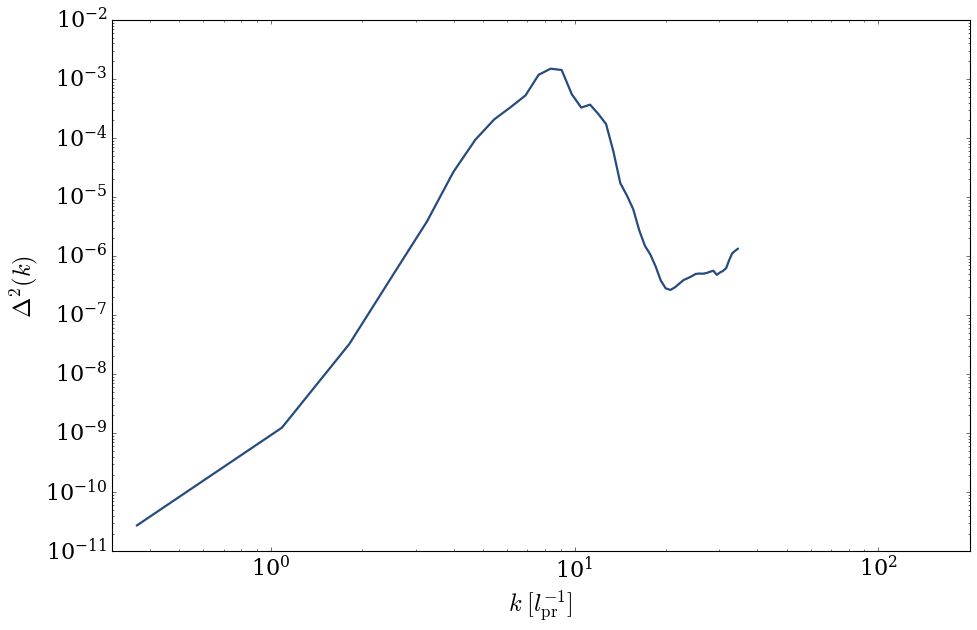

In [72]:
fig, ax = plt.subplots()

#ax.loglog(bin_centers,spectrum,color=cp[0],lw=2) # dimensionful power spectrum
ax.loglog(bin_centers,spectrum*bin_centers**3/(2*np.pi**2),color=cp[0],lw=2) #dimensionless power spectrum

ax.set_xlim(0.3,2e2)

ax.set_xlabel(r'$k\;[l_\mathrm{pr}^{-1}]$')
ax.set_ylabel(r'$\Delta^2(k)$')

### Plot overdensity field

In [10]:
overdens_t = overdens.transpose()

Text(0, 0.5, '$y\\;[l_\\mathrm{pr}]$')

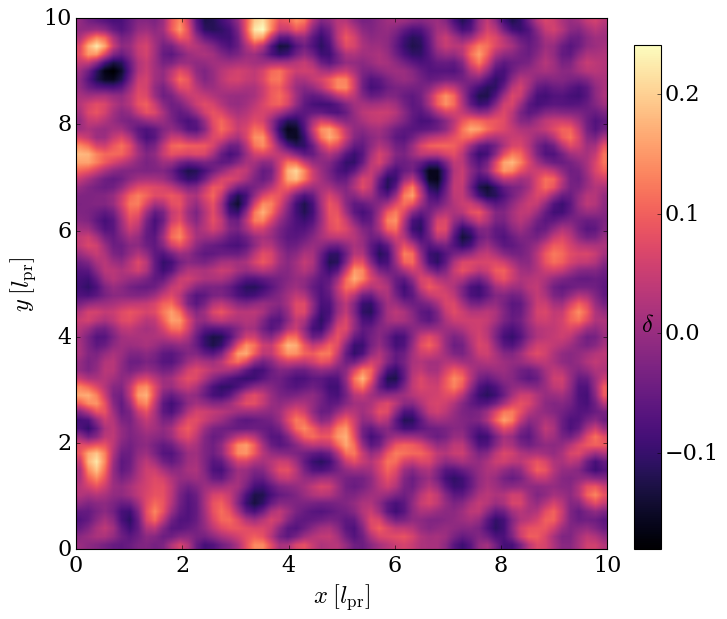

In [11]:
fig, ax = plt.subplots()

cax = ax.imshow(overdens_t[int(N/2),:,:],cmap='magma', extent=(0, 10, 0, 10), origin='lower')

axins = inset_axes(ax,
                   width="5%",  # width = 5% of parent_bbox width
                   height="95%",  # height : 50%
                   loc='lower left',
                   bbox_to_anchor=(1.05, 0., 1.0, 1),
                   bbox_transform=ax.transAxes,
                   borderpad=0.0,
                   )

cb = fig.colorbar(cax,cax = axins, ticks=[-0.1, 0.0, 0.1, 0.2])
# cb.ax.text(0.25, 0.265, r'$\delta$',fontsize=22)
cb.ax.text(0.25, 0.002, r'$\delta$',fontsize=22)

ax.set_xlabel('$x\;[l_\mathrm{pr}]$')
ax.set_ylabel('$y\;[l_\mathrm{pr}]$')

### evolution of field, Hubble and $w$

In [12]:
ix = 86000

a1 = np.loadtxt(path_kg+'runlog')[:,3][:ix]
ap1 = np.loadtxt(path_kg+'runlog')[:,4][:ix]
phi1 = np.loadtxt(path_kg+'runlog')[:,7][:ix]
phidot1 = np.loadtxt(path_kg+'runlog')[:,8][:ix]

H_phys = B*ap1*a1**(s-1) # in Planck mass

rho_t1 = np.loadtxt(path_kg+'rholog')[:,2][:ix]
rho_v1 = np.loadtxt(path_kg+'rholog')[:,4][:ix]
rho_g1 = np.loadtxt(path_kg+'rholog')[:,3][:ix]

err = np.loadtxt(path_kg+'runlog')[:,-2][:ix]


coeff = B**2/A**2*a1**(2*s-2*r) # conversion factor from program energy density to physical dens
rho_tot = coeff*(rho_t1+rho_v1+rho_g1)

w = (rho_t1 - rho_v1)/(rho_t1 + rho_v1)

FileNotFoundError: /user/niki.suckau/u10965/.project/dir.scratch-scc/scalarverse/Exec/Inflation/ComovSingleField/Output_64/rholog not found.

In [12]:
plt.style.use('classic')

def figsize(scale):
     fig_width_pt = 1000 #510.0 #from /the/textwidth for paper!!!                       # Get this from LaTeX using \the\textwidth -> 415.41025, for multiplot side by side: 450.41025
     inches_per_pt = 1.0/72.27                       # Convert pt to inch
     golden_mean = (np.sqrt(5.0)-0.4)/2.0            # Aesthetic ratio (changed from -1.0 to -0.9)
     fig_width = fig_width_pt*inches_per_pt*scale    # width in inches, for dedicated and all emissions: 0.5*...
     fig_height = fig_width   #0.6       # height in inches, for dedicated and all emissions: 2*..., for rew012: 0.4*...
     fig_size = [fig_width,fig_height]
     return fig_size


font = {
    'font.family':'serif',
    'font.style': 'normal',
    'axes.labelsize': 22, #10
    'legend.fontsize': 20, #8
    'xtick.labelsize': 20, #8
    'ytick.labelsize': 20, #8
    'figure.figsize': figsize(1.0),
}
mpl.rcParams.update(font)
#mpl.rcParams['axes.linewidth'] = 1.5 #set the value globally

mpl.rcParams['figure.facecolor'] = 'w'

In [ ]:
fig1, axes = plt.subplots(nrows=4,ncols=1,sharex=True)

axes[0].plot(a1,phi1/M,color=cp[0],lw=2)
axes[1].semilogy(a1,H_phys/m,color=cp[0],lw=2)
axes[1].semilogy(a1,H_phys[-1]*(a1/a1[-1])**(-1.5)/m,color=cp[1],lw=2,ls='--',dashes=(3,2))
axes[2].plot(a1,w,color=cp[0],lw=2)
axes[2].axhline(0,color='black',lw=2,ls='--',dashes=(3,2))
axes[3].plot(a1,(err-1)*100,color=cp[0],lw=1.5)
axes[3].axhline(0,color='black',lw=2,ls='--',dashes=(3,2))

axes[3].set_xlim(0.75,a1[-1]+0.5)
axes[0].set_ylim(-5,17.5)
axes[1].set_ylim(7e-4,3e-1)
axes[2].set_ylim(-1.25,1.25)
axes[3].set_ylim(-1.,1.)

axes[3].set_yticks([-0.9,-0.6,-0.3,0.0,0.3,0.6,0.9])

axes[0].set_ylabel(r'$\bar\varphi/M$')
axes[1].set_ylabel(r'$H/m$')
axes[2].set_ylabel(r'$w$')
#axes[3].set_ylabel(r'$H^2/(8\pi G\rho/3)-1\;[\%]$')
axes[3].set_ylabel(r'$\mathrm{num.}\;\,\mathrm{error}\;[\%]$')
axes[3].set_xlabel('$a$',labelpad=0.5)

### Unit system for SP run

In [14]:
import astropy.units as u
from astropy.constants import hbar, c, G, M_sun

m_pl = np.sqrt(hbar*c/G).to(u.GeV, equivalencies=u.mass_energy())   # Planck mass
m_p = m_pl.to('eV').value # in eV

In [ ]:
a_f = np.loadtxt(path_kg+'runlog')[86000,3] #final scale factor and derivative
ap_f = np.loadtxt(path_kg+'runlog')[86000,4]
print(a_f,ap_f)

L_phys_res = 10/(B*m_p*5.07e6)*a_f # at the end of resonance, physical box size

N_sp = 4.0 # e-folds of additional expansion in SP solver

l_u = L_phys_res*np.exp(N_sp) # in m

m_u = 1e-10 # in kg
G_u = 1e-10 # in l_u^3/(m_u t_u^2)
t_u = np.sqrt(G_u/(6.67e-11)*l_u**3/m_u) # in s

L_nyx = L_phys_res*np.exp(N_sp)
print('Length unit in m: ',l_u)
print('Comoving box size in Nyx: ',L_nyx/l_u)
print('Mass unit in kg: ',m_u)
print('Time unit in s: ',t_u)

In [ ]:
H_phys_f = B*ap_f*a_f**(s-1)*m_p* 1.52e15/(1/t_u) * np.exp(-1.5*N_sp) # in 1/t_u
print('Hubble parameter at final snapshot of SP run: ',H_phys_f)

In [ ]:
coeff = m_p**4*1.78e-36*(5.07e6)**3/m_u*l_u**3 # conversion factor from m_p^4 to m_u/l_u^3
print(coeff, np.sqrt(coeff)) # sqrt(coeff) as coefficient required in conversion of wave function in Axionyx

In [ ]:
# when using this value of hbaroverm in this unit system, use m_tt = 1 in nyx inputs file.
hbar = 6.582e-16 # in eV s
hbaroverm = hbar/(m*m_p/(c.value)**2) *t_u/l_u**2 # in l_u^2/t_u
print('inflaton mass in eV:',m*m_p)
print('hbaroverm in l_u^2/t_u:',hbaroverm)

In [ ]:
rho_mean_com = 3*H_phys_f**2/(8*np.pi*G_u) # in m_u/l_u^3 (comoving)
print('Average comoving density in m_u/l_u^3: ',rho_mean_com*1e-9)

In [ ]:
print('In Axionyx inputs file:')
print('')
print('nyx.comoving_OmM = ',1.0)
print('nyx.comoving_OmB = ',0.0)
print('nyx.comoving_h = ',H_phys_f/100)
print('nyx.initial_z = ',np.exp(N_sp) - 1.0)
print('nyx.final_z = ',0.0)
print('geometry.prob_lo =',0.0,0.0,0.0)
print('geometry.prob_hi =',L_nyx/l_u,L_nyx/l_u,L_nyx/l_u)
print('nyx.m_tt = ',1.0) 
print('')
print('-------------------')
print('Important: Use ',hbaroverm,' as value for hbaroverm in Nyx.cpp (below #INF flag)')
print('Important: Use ',np.sqrt(coeff),' as conversion coeff in initialization of wave function in Nyx_initcosmo.cpp')

# SP run

In [21]:
plt.style.use('classic')

def figsize(scale):
     fig_width_pt = 1000 #510.0 #from /the/textwidth for paper!!!                       # Get this from LaTeX using \the\textwidth -> 415.41025, for multiplot side by side: 450.41025
     inches_per_pt = 1.0/72.27                       # Convert pt to inch
     golden_mean = (np.sqrt(5.0)-0.4)/2.0            # Aesthetic ratio (changed from -1.0 to -0.9)
     fig_width = fig_width_pt*inches_per_pt*scale    # width in inches, for dedicated and all emissions: 0.5*...
     fig_height = fig_width*0.6   #0.6       # height in inches, for dedicated and all emissions: 2*..., for rew012: 0.4*...
     fig_size = [fig_width,fig_height]
     return fig_size


font = {
    'font.family':'serif',
    'font.style': 'normal',
    'axes.labelsize': 22, #10
    'legend.fontsize': 20, #8
    'xtick.labelsize': 20, #8
    'ytick.labelsize': 20, #8
    'figure.figsize': figsize(1.0),
}
mpl.rcParams.update(font)
#mpl.rcParams['axes.linewidth'] = 1.5 #set the value globally
    

#mpl.rcParams['axes.linewidth'] = 1.25 #set the value globally 
mpl.rcParams['figure.facecolor'] = 'w'

cp = [(0.14573579, 0.29354139, 0.49847009), (0.9333333333333333, 0.5215686274509804, 0.2901960784313726),(0.48942421, 0.72854938, 0.56751036)]


### read in SP initial snapshot

In [ ]:
path_sp = '/home/uni09/cosmo/beggeme/early_universe/post_resonance/SP/'
ds = yt.load(path_sp+'plt00000',hint='NyxDataset')

ds._get_field_info('boxlib', 'AxDens').units='code_density' 
ds._get_field_info('boxlib', 'AxDens').output_units='Msun/Mpc**3' 

ds.field_list outputs fields stored in snapshot: 
 - 'AxDens' is the total energy density
 - 'AxRe' is the real part of the wavefunction
 - 'AxIm' is the imaginary part of the wavefunction
 - 'AxPhas' is the phase of the wavefunction
 - 'phi_grav' is the gravitational potential

In [ ]:
ds.field_list

### Plot density field 
(The units in this plot are physical code units [m_u/l_u^3 instead of $M_\odot$/Mpc^3], i.e. the scale factor evolution is taken into account. That's why box is smaller than the boxmoving box size of 1.0 in code units which is reached after 4 e-folds of expansion.)

In [ ]:
slc = yt.SlicePlot(ds,'z','AxDens')
slc.show()

### compute and plot power spectrum, compare it to KG final spectrum

In [25]:
max_level = ds.index.max_level
ref = int(np.product(ds.ref_factors[0:max_level]))
low = ds.domain_left_edge
dims = ds.domain_dimensions*ref
# covering_grid guarantess that all grids are read in properly [density field is not mixed up]
cube = ds.covering_grid(level=max_level, left_edge=low,dims=dims,fields=['AxDens']) 
dens = cube['AxDens'].value # in code units
overdens = dens/np.mean(dens) - 1

# Fourier transform to compute power spectrum

kxList = np.fft.fftfreq(N,dx)*2.0*np.pi
kx3d, ky3d, kz3d = np.meshgrid(kxList, kxList, kxList, indexing="ij")
kk = np.sqrt(kx3d**2 + ky3d**2 + kz3d**2)
spectrum_3D = np.abs(np.fft.fftn(overdens)*(dx**3))**2/L**3 
spectrum_sp, bin_edges, bin_number = binned_statistic(kk.flat[:],spectrum_3D.flat[:],statistic='mean',bins=0.75*N)
bin_centers_sp = 0.5*(bin_edges[0:-1] + bin_edges[1:])
bin_width   = bin_edges[1]-bin_edges[0]

In [ ]:
fig, ax = plt.subplots()

ax.loglog(bin_centers_sp,spectrum_sp*bin_centers_sp**3/(2*np.pi**2),color=cp[0],lw=2) #dimless SP initial power spectrum
ax.loglog(bin_centers,spectrum*bin_centers**3/(2*np.pi**2),color=cp[1],lw=2,ls='--') #dimless KG final power spectrum

ax.set_xlim(0.3,2e2)

ax.set_xlabel(r'$k\;[l_\mathrm{pr}^{-1}]$')
ax.set_ylabel(r'$\Delta^2(k)$')